In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [49]:
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')

In [50]:
df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


the goal of this project is to analyze student test performance

pick any school in this dataset as an initial comparison point

pick a feature/measure/score

compare above school to schools in the entire dataset, schools in a particular borough, or schools in a particular district - you only need to do one additional comparison point (but you’re welcome to do more comparisons if you feel compelled to do so)

the analysis should include some descriptive statistics

the analysis should include one cleaning task (or more)

the analysis should include one visualization (or more)

the analysis should include a brief conclusion statement (not more than two or three sentences)

In [51]:
#look at the first 20 rows
df.head(20)

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na
5,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2015,9,67.4,3,33.3,6,66.7,0,0,na,na
6,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2016,15,72.6,2,13.3,13,86.7,5,33.3,na,na
7,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2017,9,64.4,5,55.6,4,44.4,1,11.1,na,na
8,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2015,49,78.4,1,2,48,98,23,46.9,48,98
9,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2016,51,79,9,17.6,42,82.4,33,64.7,40,78.4


In [52]:
#bottom 20 rows
df.tail(20)

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
212311,84X706,Harriet Tubman Charter School,K-8,Common Core Algebra,2017,15,82.6,0,0,15,100,12,80,15,100
212312,84X706,Harriet Tubman Charter School,K-8,Common Core Algebra,2017,7,s,s,s,s,s,s,s,na,na
212313,84X706,Harriet Tubman Charter School,K-8,Common Core Algebra,2017,1,s,s,s,s,s,s,s,na,na
212314,84X706,Harriet Tubman Charter School,K-8,Integrated Algebra,2015,13,s,s,s,s,s,s,s,na,na
212315,84X706,Harriet Tubman Charter School,K-8,Integrated Algebra,2015,3,s,s,s,s,s,s,s,na,na
212316,84X706,Harriet Tubman Charter School,K-8,Living Environment,2015,1,s,s,s,s,s,s,s,na,na
212317,84X706,Harriet Tubman Charter School,K-8,U.S. History and Government,2017,3,s,s,s,s,s,s,s,na,na
212318,84X717,Icahn Charter School,K-8,Common Core Algebra,2015,5,s,s,s,s,s,s,s,na,na
212319,84X717,Icahn Charter School,K-8,Common Core Algebra,2015,2,s,s,s,s,s,s,s,na,na
212320,84X717,Icahn Charter School,K-8,Common Core Algebra,2016,8,87.9,0,0,8,100,7,87.5,8,100


In [53]:
#check rows, columns numbers
df.shape

(212331, 15)

In [54]:
#data types and missing values; most things are an object
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212331 entries, 0 to 212330
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   School DBN                   212331 non-null  object
 1   School Name                  212331 non-null  object
 2   School Level                 212331 non-null  object
 3   Regents Exam                 212321 non-null  object
 4   Year                         212331 non-null  int64 
 5   Total Tested                 212331 non-null  int64 
 6   Mean Score                   212331 non-null  object
 7   Number Scoring Below 65      212331 non-null  object
 8   Percent Scoring Below 65     212331 non-null  object
 9   Number Scoring 65 or Above   212331 non-null  object
 10  Percent Scoring 65 or Above  212331 non-null  object
 11  Number Scoring 80 or Above   212331 non-null  object
 12  Percent Scoring 80 or Above  212331 non-null  object
 13  Number Scoring

In [55]:
df.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

In [56]:
print(df.head())

  School DBN                     School Name School Level  \
0     01M034  P.S. 034 Franklin D. Roosevelt          K-8   
1     01M034  P.S. 034 Franklin D. Roosevelt          K-8   
2     01M034  P.S. 034 Franklin D. Roosevelt          K-8   
3     01M140          P.S. 140 Nathan Straus          K-8   
4     01M140          P.S. 140 Nathan Straus          K-8   

          Regents Exam  Year  Total Tested Mean Score Number Scoring Below 65  \
0  Common Core Algebra  2017             4          s                       s   
1   Living Environment  2015            16       77.9                       1   
2   Living Environment  2016             9         74                       1   
3  Common Core Algebra  2016             3          s                       s   
4  Common Core Algebra  2017             2          s                       s   

  Percent Scoring Below 65 Number Scoring 65 or Above  \
0                        s                          s   
1                      6.3      

In [57]:
#for things I expect to be a number like mean score,
#I want to convert it to a number instead of object
#so I'm checking why it's an object
#looks like there's a "s" in the first line
df['Mean Score'].unique()

array(['s', '77.9', '74', '67.4', '72.6', '64.4', '78.4', '79', '84.8',
       '83.9', '62.9', '69', '62.1', '52.3', '63.9', '67.5', '48', '61.5',
       '67.2', '77.2', '49.2', '56.8', '63', '51.6', '57.8', '54.2',
       '59.8', '59.3', '63.4', '51.7', '55.4', '63.2', '65', '45', '45.3',
       '53.4', '71.7', '56.2', '71.9', '80.7', '78', '72.9', '62.2',
       '58.6', '62.6', '68.2', '67.3', '64.9', '69.2', '73.9', '73.1',
       '56.4', '60.9', '65.1', '57.1', '68.5', '55.1', '65.8', '68', '72',
       '65.7', '71.8', '67.7', '69.8', '72.7', '64.8', '72.1', '70.5',
       '76.7', '76.9', '78.2', '79.5', '82.2', '79.7', '74.6', '71.2',
       '49.3', '60.5', '64.5', '61.6', '42', '50.1', '52.2', '57.3',
       '54.8', '44.3', '51', '74.2', '50.9', '61.3', '65.5', '59.9',
       '51.8', '64', '55.3', '62.8', '54.4', '57', '60.3', '64.1', '63.7',
       '73.5', '50.5', '59.7', '39.6', '79.1', '85.4', '77.7', '78.1',
       '77', '70.2', '76', '74.3', '71', '73.7', '80.6', '77.6', '77

In [58]:
#cleaning up data
#convert s to number without messing with the mean

#printing clean mean data to see what rows have "s"
cleaned_meandata = df[df['Mean Score'] == 's']
print(cleaned_meandata)

       School DBN                     School Name School Level  \
0          01M034  P.S. 034 Franklin D. Roosevelt          K-8   
3          01M140          P.S. 140 Nathan Straus          K-8   
4          01M140          P.S. 140 Nathan Straus          K-8   
15         01M188      P.S. 188 The Island School          K-8   
17         01M188      P.S. 188 The Island School          K-8   
...           ...                             ...          ...   
212326     84X717            Icahn Charter School          K-8   
212327     84X717            Icahn Charter School          K-8   
212328     84X717            Icahn Charter School          K-8   
212329     84X717            Icahn Charter School          K-8   
212330     84X717            Icahn Charter School          K-8   

                       Regents Exam  Year  Total Tested Mean Score  \
0               Common Core Algebra  2017             4          s   
3               Common Core Algebra  2016             3          s 

In [59]:
#using numpy to replace all the "s" with "nan"/NaN or not available number
#I would have replaced it with 0 but that will skew mean averages/numbers
df['Mean Score'] = df['Mean Score'].replace('s', np.nan)
df['Mean Score'] = df['Mean Score'].astype(float)
print("\nFirst 10 values in 'Mean Score':")
print(df['Mean Score'].head(10))


First 10 values in 'Mean Score':
0     NaN
1    77.9
2    74.0
3     NaN
4     NaN
5    67.4
6    72.6
7    64.4
8    78.4
9    79.0
Name: Mean Score, dtype: float64


In [60]:
#First research question I want to ask:???
#choosing my schools for comparison

In [61]:
#looking for a specific school (hs)
siths_results = df[df['School Name'].str.contains('Staten Island', case=False, na=False)]
print(siths_results['School Name'].unique())

['The Eagle Academy for Young Men of Staten Island' 'Staten Island Yabc'
 'Staten Island Technical High School'
 'Staten Island School of Civic Leadership']


In [62]:
#looking for a specific school (hs competition)
stuy_results = df[df['School Name'].str.contains('Stuy', case=False, na=False)]
print(stuy_results['School Name'].unique())

['Stuyvesant High School' 'Bedford Stuyvesant Preparatory High School'
 'Leadership Prep Bedford Stuyvesant Uncommon Prep C'
 'Bedford Stuyvesant Collegiate Charter School'
 'Bedford Stuyvesant New Beginnings Charter School']


In [63]:
#selecting schools for my analysis by listing out the two schools I want to compare

schools_of_interest = ['Staten Island Technical High School', 'Stuyvesant High School']
comparison_df = df[df['School Name'].isin(schools_of_interest)]
print(comparison_df['School Name'].unique())

['Stuyvesant High School' 'Staten Island Technical High School']


In [64]:
#created subset for school
school1_df = df[df['School Name'] == 'Staten Island Technical High School']
print(school1_df['Regents Exam'].value_counts())

Regents Exam
Living Environment              36
Physical Settings/Chemistry     36
Physical Settings/Physics       36
Global History and Geography    36
U.S. History and Government     35
Common Core Algebra             35
Common Core Geometry            34
Algebra2/Trigonometry           24
Common Core English             24
Common Core Algebra2            23
English                         12
Geometry                        11
Name: count, dtype: int64


In [65]:
#created subset for school
school2_df = df[df['School Name'] == 'Stuyvesant High School']
print(school2_df['Regents Exam'].value_counts())

Regents Exam
Common Core Geometry            38
Living Environment              38
Physical Settings/Physics       36
Global History and Geography    36
Physical Settings/Chemistry     36
U.S. History and Government     36
Common Core Algebra             35
Algebra2/Trigonometry           24
Common Core Algebra2            24
Common Core English             24
English                         19
Geometry                        19
Integrated Algebra              12
Name: count, dtype: int64


In [66]:
#looks like my chosen above schools do not have too much data
#checking other options
print(df['School Name'].value_counts().head(30))

School Name
New Visions Charter High School for Advanced Math     1337
New Visions Charter High School for the Humanities    1031
James Madison High School                              490
Francis Lewis High School                              490
Long Island City High School                           489
Edward R. Murrow High School                           489
John Dewey High School                                 488
Forest Hills High School                               486
Benjamin N. Cardozo High School                        486
New Dorp High School                                   485
John Bowne High School                                 484
Tottenville High School                                484
John Adams High School                                 484
Robert H. Goddard High School of Communication Art     481
Academy of Finance and Enterprise                      480
New Utrecht High School                                480
Port Richmond High School                   

In [67]:
#other highschool comparisons
#schools_of_interest = ['John Dewey High School', 'New Dorp High School']
#comparison_df = df[df['School Name'].isin(schools_of_interest)]
#print(comparison_df['School Name'].unique())

In [68]:
#Comparison 1: mean score
#create subsets above for each school
#coercing ensures mean score is numeric before calculating. I did it above but
#redoing "coerce" here to change non numbers to NaN / readable
#using "group by" to compare both schools' mean scores/performance
comparison_df['Mean Score'] = pd.to_numeric(comparison_df['Mean Score'], errors='coerce')
print(comparison_df.groupby('School Name')['Mean Score'].describe())

                                     count       mean       std   min    25%  \
School Name                                                                    
Staten Island Technical High School  224.0  88.862500  4.280577  77.4  85.50   
Stuyvesant High School               271.0  91.697786  3.353151  81.1  89.35   

                                      50%   75%   max  
School Name                                            
Staten Island Technical High School  88.9  92.1  96.3  
Stuyvesant High School               92.5  94.0  97.4  


/tmp/ipykernel_519/2866504514.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comparison_df['Mean Score'] = pd.to_numeric(comparison_df['Mean Score'], errors='coerce')


<Axes: xlabel='School Name', ylabel='Mean Score'>

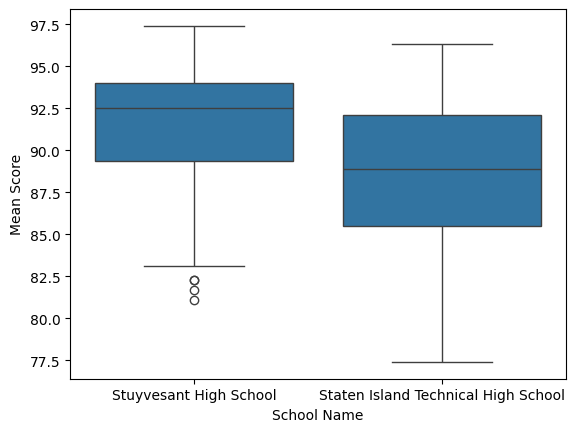

In [69]:
#to visualize the above:
#to explain: Stuyvesant performs better than SI Tech on average
# the standard deviation for Stuy is relatively consistent at 3.35
# the standard deviation for SI Tech is spread out more at 4.28. You can
#see how the box is bigger/taller than Stuy's in comparison
sns.boxplot(data=comparison_df, x='School Name', y='Mean Score')